In [37]:
##Let's import librariesimport pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [38]:
df=pd.read_csv('/content/medical_insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [39]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [40]:
# checking for a null values

print([df.describe()],[df.isnull().sum()])

[               age          bmi     children       charges
count  2772.000000  2772.000000  2772.000000   2772.000000
mean     39.109668    30.701349     1.101732  13261.369959
std      14.081459     6.129449     1.214806  12151.768945
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.220000     0.000000   4687.797000
50%      39.000000    30.447500     1.000000   9333.014350
75%      51.000000    34.770000     2.000000  16577.779500
max      64.000000    53.130000     5.000000  63770.428010] [age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64]


In [41]:
#data visualization

In [42]:
df.duplicated().sum()


np.int64(1435)

In [43]:
#EDA
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


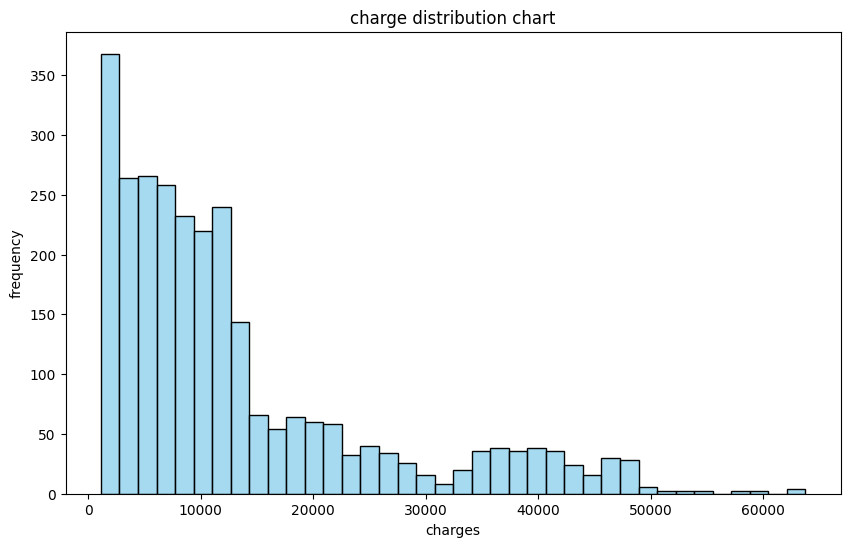

In [44]:
#histogram for charge
plt.figure(figsize=(10,6))
sns.histplot(df['charges'],edgecolor='black',color='skyblue')
plt.title('charge distribution chart')
plt.xlabel('charges')
plt.ylabel('frequency')
plt.show()

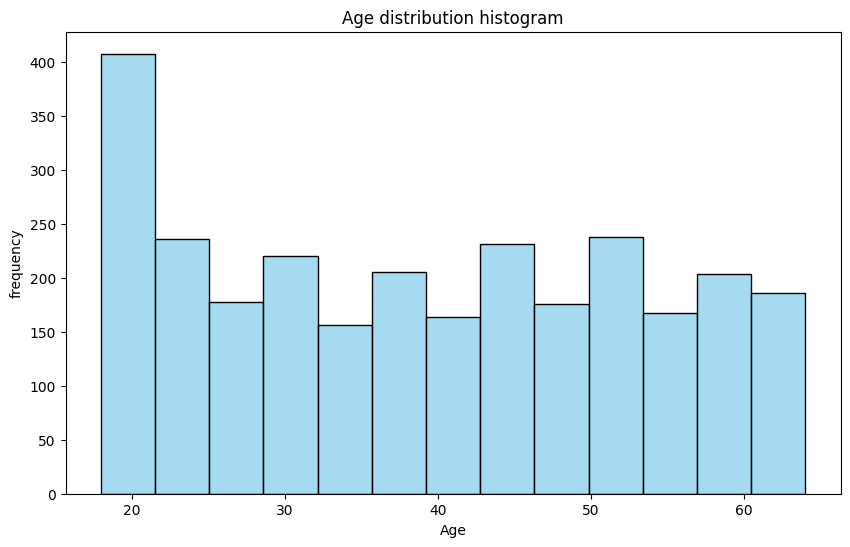

In [45]:
#histogram for age
plt.figure(figsize=(10,6))
sns.histplot(df['age'],edgecolor='black',color='skyblue')
plt.title('Age distribution histogram')
plt.xlabel('Age')
plt.ylabel('frequency')
plt.show()

Text(0, 0.5, 'frequency')

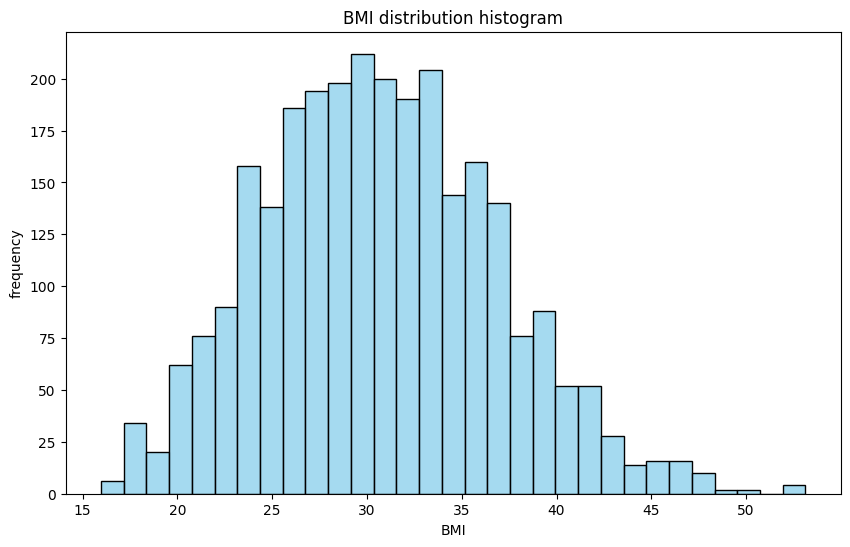

In [46]:
#histogram for BMI
plt.figure(figsize=(10,6))
sns.histplot(df['bmi'],edgecolor='black',color='skyblue')
plt.title('BMI distribution histogram')
plt.xlabel('BMI')
plt.ylabel('frequency')

Text(0, 0.5, 'frequency')

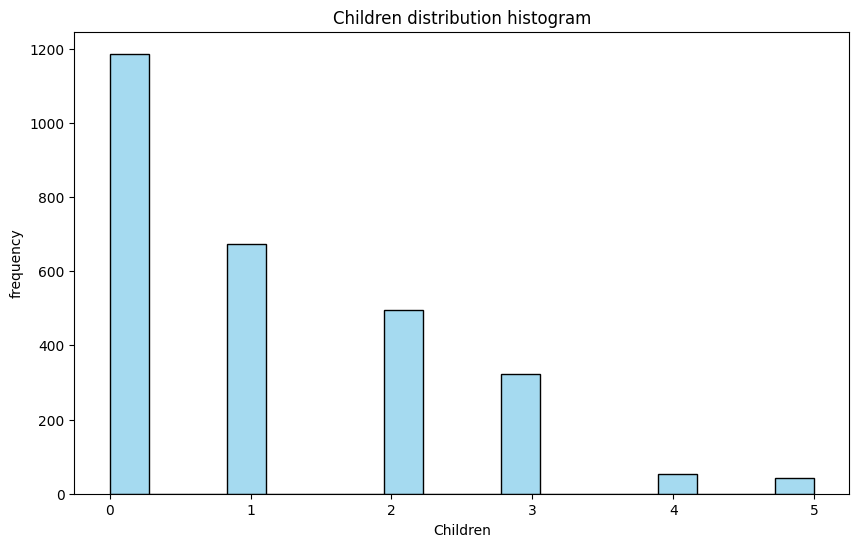

In [47]:
#histogram for childrens
plt.figure(figsize=(10,6))
sns.histplot(df['children'],edgecolor='black',color='skyblue')
plt.title('Children distribution histogram')
plt.xlabel('Children')
plt.ylabel('frequency')

In [48]:
# encoding of data by one hot encoding(have feature of drop one column)
df=pd.get_dummies(df,drop_first=True)
print(df.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


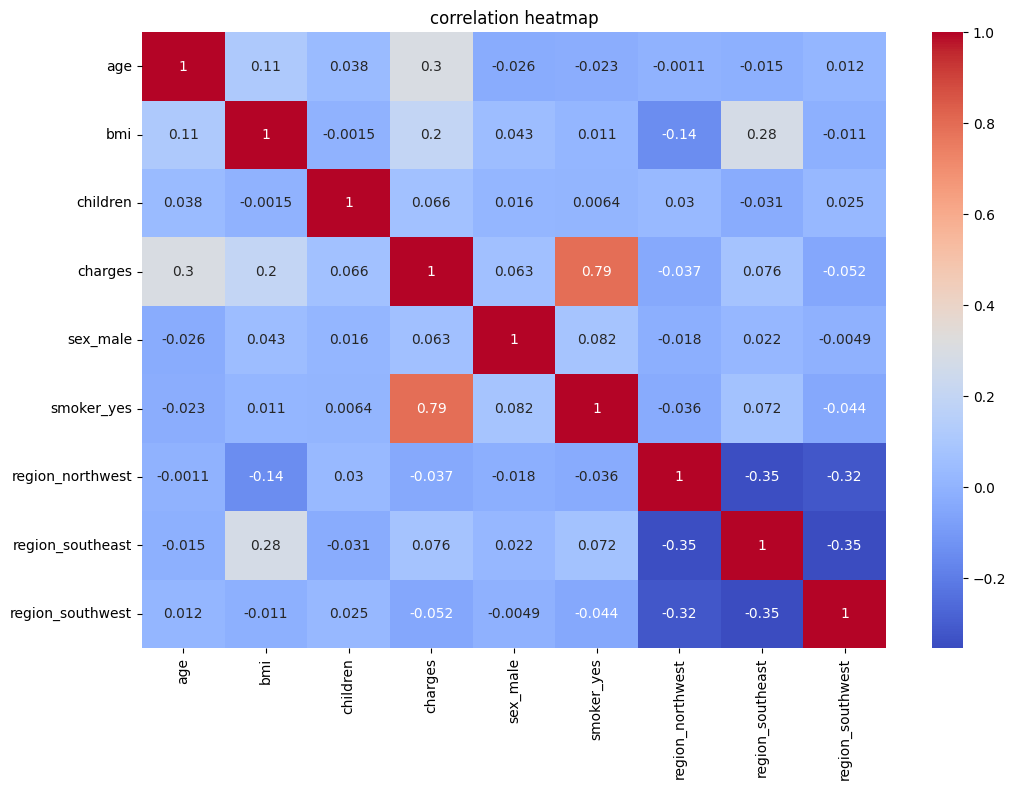

In [49]:
# hypothesis testing
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
# spliting data

x=df.drop('charges',axis=1)
y=df['charges']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
#linear regression
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("model training is complete")

model is complete


In [53]:
# model work
y_pred=model.predict(x_test)
comparison=pd.DataFrame({'Actual':y_test.head(),'Predicted':y_pred[:5]})
print(comparison)

           Actual     Predicted
1106   8988.15875  10382.195851
1321  28101.33305  36850.703702
2313  12032.32600   9010.642378
2274   1682.59700   5910.228930
1432   3393.35635   6661.467930


In [54]:
from sklearn.metrics import mean_squared_error,r2_score
score=r2_score(y_test,y_pred)
print(f"Model Accuracy(R-squared): {score*100:.2f}%")

Model Accuracy(R-squared): 73.98%
